#### To Do:

- fix with Amelie that the names are the same of all the files: easier! 
- How to control for noise ==> curve_4 => noise after sec 6 (i think) -> how to fix it?
- link segment time with angle time !! -> fix data qtm: naming + conversion to opensim: GRF included: easier to calculate contact time

In [1]:
# load the project root into the notebook to be able to load functions from other modules
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tests":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
from Base.Opensim_analysis_code import angle_plot, analyze_folder_OS, merge_left_contacts, get_mat_data
from Base.GRF_analysis_code import analyze_folder_segm

print(os.getcwd())

/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests
/Users/ernstdavidts/Library/CloudStorage/OneDrive-UGent/Master I/Oslo/Curved_Running_Pilot/Base/tests


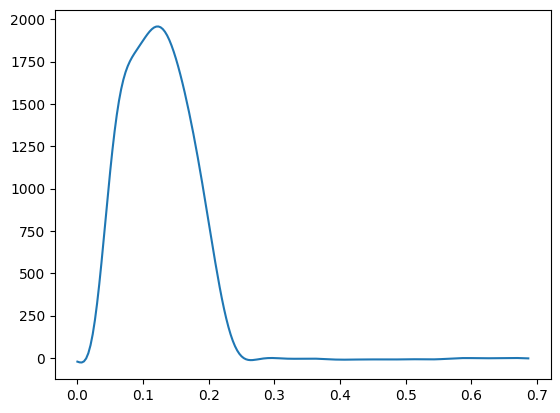

In [3]:
folder = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "files")
df_segm = analyze_folder_segm(folder)
# df = loadmat("../../files/OpenSim3/MOD_ED_Shoe25OpenSim_python.mat", squeeze_me=True, struct_as_record=False)
# print(df.keys())
# labels = df["labels"].ANGLES_TABLE
# label = labels._fieldnames
# trial_data = df["ANGLES_TABLE"]
# for name in trial_data._fieldnames:
#     trial_data.name
#     angle_label = trial_data.name
#     print(angle_label)
# angles = trial_data.x25_Curve_1_mat
# print(angles)

df = get_mat_data("../../files/OpenSim3/MOD_ED_Shoe25OpenSim_python.mat", variable="forces")
x = df["x25_Curve_2"]["time"]
VGRF = df["x25_Curve_2"]["ground_force1_vy"]

plt.figure()
plt.plot(x, VGRF)
plt.show()

# labels = df["labels"][0,0][0][0][0][0][0]
# trial_dict = {}
# for name in trial_angle.dtype.names:
#     print(name)
#     values = trial_angle[name]
    
#     for i in range(len(values[0,:])):
#         trial_dict[name] = pd.DataFrame(values, columns=labels)


# labels = df["labels"][0,0][0][0][0][0][0]
# for i in range(len(labels)):
#     label = 
#     print(label)

# df.keys()
# tryout1 = loadmat("../../files/NEW_Shoe25OpenSim.mat")
# tryout2 = loadmat("../../files/NEW_MN_Shoe25OpenSim_FULL.mat")

# #print(tryout1["ANGLES_TABLE"][0,0])
# angles2 = tryout2["ANGLES_TABLE"][0,0]
# tryout2["GRF_TABLE"][0,0][0][:,5]


In [4]:
OS3 = analyze_folder_OS("../../files/OpenSim3")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left3 = {}
for key in OS3:
    if key.endswith("_r"):
        continue

    angle_df = OS3[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left3[key] = angle_df_stance
OS_stance_left3

{'pelvis_tilt':      participant shoe condition trial  time     value  side        IC  \
 1             ED   25     Curve     1  0.01  9.646430  None  0.003333   
 2             ED   25     Curve     1  0.02  9.286689  None  0.003333   
 3             ED   25     Curve     1  0.03  8.848503  None  0.003333   
 4             ED   25     Curve     1  0.04  8.050588  None  0.003333   
 5             ED   25     Curve     1  0.05  7.193662  None  0.003333   
 ...          ...  ...       ...   ...   ...       ...   ...       ...   
 4331          MN   25  Straight     5  0.19  3.413654  None  0.041000   
 4332          MN   25  Straight     5  0.20  4.013533  None  0.041000   
 4333          MN   25  Straight     5  0.21  4.427069  None  0.041000   
 4334          MN   25  Straight     5  0.22  4.807557  None  0.041000   
 4335          MN   25  Straight     5  0.23  5.144447  None  0.041000   
 
             TO  
 1     0.223333  
 2     0.223333  
 3     0.223333  
 4     0.223333  
 5   

In [25]:
OS = analyze_folder_OS("../../files/OpenSim")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left = {}
for key in OS:
    if key.endswith("_r"):
        continue

    angle_df = OS[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left[key] = angle_df_stance
OS

{'pelvis_tilt':    participant shoe condition trial  time      value  side
 0           MN   45     Curve     1  0.00  12.723798  None
 1           MN   45     Curve     1  0.01  12.843295  None
 2           MN   45     Curve     1  0.02  12.695810  None
 3           MN   45     Curve     1  0.03  12.377235  None
 4           MN   45     Curve     1  0.04  11.854617  None
 ..         ...  ...       ...   ...   ...        ...   ...
 68          MN   55  Straight     5  0.68 -10.816684  None
 69          MN   55  Straight     5  0.69 -18.479040  None
 70          MN   55  Straight     5  0.70 -27.395607  None
 71          MN   55  Straight     5  0.71 -36.519890  None
 72          MN   55  Straight     5  0.72 -43.108964  None
 
 [4392 rows x 7 columns],
 'pelvis_list':    participant shoe condition trial  time      value  side
 0           MN   45     Curve     1  0.00 -11.069246  None
 1           MN   45     Curve     1  0.01 -10.901935  None
 2           MN   45     Curve     1  0.02

In [ ]:
OS2 = analyze_folder_OS("../../files/OpenSim2")
left_contacts = df_segm[df_segm["plate"] == "FP1"].copy()
left_contacts["participant"] = left_contacts["participant"].replace({
    "01": "ED",
    "02": "MN"
})

left_contacts["condition"] = left_contacts["condition"].str.capitalize()
left_contacts["trial"] = left_contacts["trial"].astype(str)
left_contacts["shoe"] = left_contacts["shoe"].astype(str)

OS_stance_left2 = {}
for key in OS2:
    if key.endswith("_r"):
        continue

    angle_df = OS2[key].copy()
    angle_df_stance = merge_left_contacts(angle_df, left_contacts)
    OS_stance_left2[key] = angle_df_stance

{'pelvis_rotation':      participant shoe condition trial  time      value  side        IC  \
 1             ED   25     Curve     1  0.01  78.996462  None  0.003333   
 2             ED   25     Curve     1  0.02  79.687952  None  0.003333   
 3             ED   25     Curve     1  0.03  80.551433  None  0.003333   
 4             ED   25     Curve     1  0.04  81.634575  None  0.003333   
 5             ED   25     Curve     1  0.05  82.783502  None  0.003333   
 ...          ...  ...       ...   ...   ...        ...   ...       ...   
 4331          MN   25  Straight     5  0.19  94.017621  None  0.041000   
 4332          MN   25  Straight     5  0.20  93.700397  None  0.041000   
 4333          MN   25  Straight     5  0.21  93.612601  None  0.041000   
 4334          MN   25  Straight     5  0.22  93.532055  None  0.041000   
 4335          MN   25  Straight     5  0.23  93.545432  None  0.041000   
 
             TO  
 1     0.223333  
 2     0.223333  
 3     0.223333  
 4     

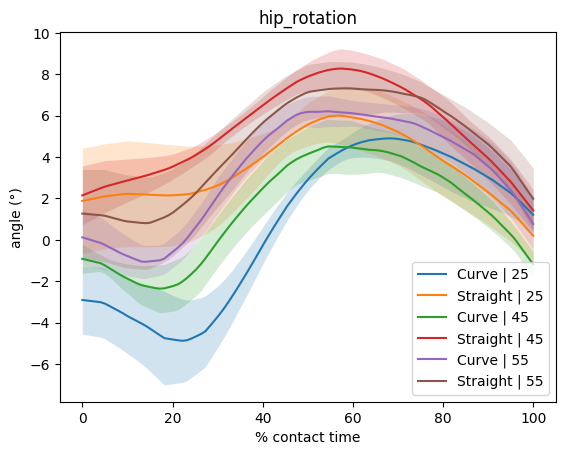

In [7]:
angle_plot(OS_stance_left3, joint= "hip_rotation", comparison= ["condition", "shoe"], side="l", participant="ED")

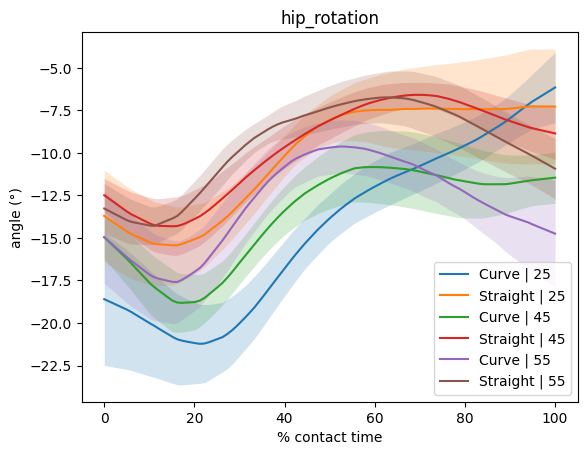

In [10]:
angle_plot(OS_stance_left, joint= "hip_rotation", comparison= ["condition", "shoe"], side="l", participant="MN")

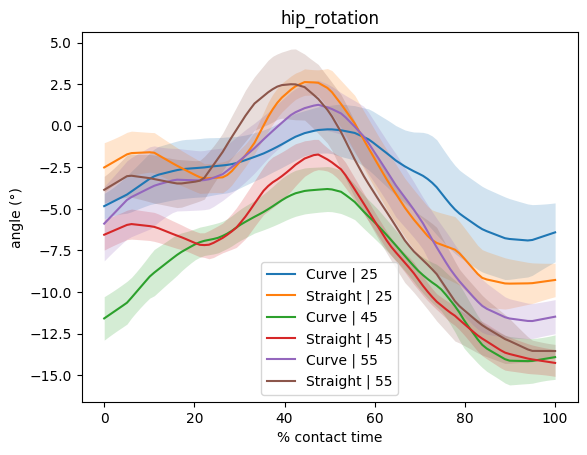

In [9]:
angle_plot(OS_stance_left2, joint= "hip_rotation", comparison= ["condition", "shoe"], side="l", participant="MN")